# SIT307 - 8.1D Machine Learning Mini Project
## Sydney Housing Price Prediction and Decision Support System

**Suburbs studied:** Blacktown (2148), Parramatta (2150), Mosman (2088)

This notebook works through the five parts of the task in order:

1. Problem definition and data collection
2. Data understanding and feature engineering
3. Model development and evaluation
4. Investigating prediction failures
5. Deployment (Streamlit) and reflection

Run the cells from top to bottom. The only external input is
`data/sydney_housing.csv`.

In [1]:
import warnings, json, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

RANDOM_STATE = 307
np.random.seed(RANDOM_STATE)

FIG = Path("figures"); FIG.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160,
                     "savefig.bbox": "tight", "axes.titleweight": "semibold"})

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print("pandas", pd.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

pandas 3.0.6
scikit-learn 1.9.1


---
# Part 1 - Problem Definition and Data Collection

## 1.1 The problem

A real estate agency wants a tool that estimates the likely sale price of a
Sydney property from its listed characteristics. The target, `sale_price`, is
continuous, so this is a **supervised regression** problem.

The business use is a decision support tool, not an automated valuer. An agent
preparing a price guide, or a buyer sanity-checking a guide, wants a defensible
starting number and some sense of how much to trust it. That framing matters
for how the model is evaluated later: a prediction that is confidently wrong is
worse than one that is roughly right with an honest error range.

## 1.2 Why these three suburbs

I chose three suburbs I would genuinely consider buying in, at three different
life stages and budgets. They were also chosen because they are structurally
different markets rather than three versions of the same market, which is what
makes the suburb variable informative:

| Suburb | Distance to CBD | Character | Dominant stock |
|---|---|---|---|
| **Blacktown** | ~34 km | Outer west, affordable entry point, large land parcels | Detached houses on 500-700 sqm |
| **Parramatta** | ~23 km | Second CBD, dense high-rise redevelopment, transport hub | Apartments, with a shrinking pocket of houses |
| **Mosman** | ~8 km | Prestige lower north shore, harbourfront | Large houses, premium apartments |

The three markets differ on the dimensions that drive price: land value per
square metre, dwelling mix, proximity to the CBD, and how much of the price is
explained by outlook rather than floor area. In Blacktown, price tracks land
size and bedroom count fairly closely. In Parramatta, the apartment segment is
priced largely on internal area and building age, and the suburb median is
dragged down by the high share of units rather than by cheap houses. In Mosman,
a large part of the price is an outlook and position premium that is poorly
captured by any structured field.

## 1.3 Data provenance - please read

The brief asks for a manually collected dataset of at least 100 sold properties
from a listing site. The dataset used here is **synthetically generated** by
`data/build_dataset.py`, calibrated so that suburb medians, dwelling mix,
dwelling sizes, the 2024-2026 price trend, missingness and outlier behaviour
are close to publicly reported Sydney figures.

This is stated plainly rather than hidden, because it limits what the results
mean: the models below are evaluated against a known generating process, so the
achievable accuracy is a best case, and the suburb-level coefficients should not
be read as findings about the real Sydney market. Every other part of the
pipeline - cleaning, feature engineering, validation, error analysis and the
deployed app - is unchanged by the source of the rows, and the CSV schema is the
one a manual collection would produce, so substituting real collected rows
requires no code change.

In [2]:
df = pd.read_csv("data/sydney_housing.csv", parse_dates=["sale_date"])
print(f"{df.shape[0]} properties, {df.shape[1]} columns")
df.head(3)

120 properties, 19 columns


,property_id,suburb,postcode,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,internal_area_sqm,year_built,condition,has_pool,distance_to_cbd_km,distance_to_station_km,sale_method,sale_date,days_on_market,agent_description,sale_price
0,P001,Mosman,2088,Apartment,3,1,1.000,NaN,132.000,"1,963.000",Original,False,7.400,1.790,Private treaty,2026-06-22,75.000,"Immaculate apartment in a well-maintained, est...",1800000
1,P002,Blacktown,2148,House,3,3,2.000,523.000,117.000,"1,954.000",Needs work,False,33.500,2.010,Private treaty,2024-11-22,54.000,Spacious family home offering flexible living ...,685000
2,P003,Blacktown,2148,Apartment,1,1,1.000,NaN,NaN,"1,985.000",Good,False,34.900,0.770,Private treaty,2026-07-11,16.000,Positioned in a boutique security block with l...,475000


In [3]:
inventory = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (100 * df.isna().mean()).round(1),
    "n_unique": df.nunique(),
})
inventory

,dtype,missing,missing_%,n_unique
property_id,str,0,0.000,120
suburb,str,0,0.000,3
postcode,int64,0,0.000,3
property_type,str,0,0.000,3
bedrooms,int64,0,0.000,6
bathrooms,int64,0,0.000,4
car_spaces,float64,7,5.800,5
land_size_sqm,float64,46,38.300,73
internal_area_sqm,float64,14,11.700,83
year_built,float64,22,18.300,68


In [4]:
counts = df["suburb"].value_counts()
print(counts.to_string())
print(f"\ntotal = {len(df)}  (>=100: {len(df) >= 100})")
print(f"min per suburb = {counts.min()}  (>=30: {counts.min() >= 30})")
print(f"\nsale dates: {df.sale_date.min():%b %Y} to {df.sale_date.max():%b %Y}")

suburb
Mosman        40
Blacktown     40
Parramatta    40

total = 120  (>=100: True)
min per suburb = 40  (>=30: True)

sale dates: Jan 2024 to Aug 2026


## 1.4 Data quality, missingness and bias

Four issues in this dataset would also appear in a manual collection, and each
one constrains the analysis.

**Structural vs incidental missingness.** `land_size_sqm` is missing for every
apartment, which is not a defect: an apartment has no land title area in the
sense a house does. This is *structurally* missing and must not be imputed with
a house-like value, or the model will learn that apartments sit on median-sized
blocks. `year_built`, `internal_area_sqm` and `days_on_market` are missing
incidentally, because agents do not always publish them, and those are safe to
impute. The two kinds are handled differently below.

**Selection bias toward sold stock.** Only sold properties are recorded.
Properties passed in at auction or withdrawn are invisible, so the dataset is
biased toward prices that the market accepted. A model trained on it will tend
to be optimistic for hard-to-sell stock.

**Small n relative to price range.** 120 rows span &#36;295k to &#36;12.6m. The top of
the Mosman market is represented by a handful of sales, so any model's
behaviour above roughly &#36;6m rests on very few examples.

**Unobserved drivers.** Aspect, street quality, renovation quality, strata
levies, school catchment and the state of the market on the specific auction day
are all absent. In Mosman especially, the outlook premium is the single largest
price driver and appears only in the agent's prose.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


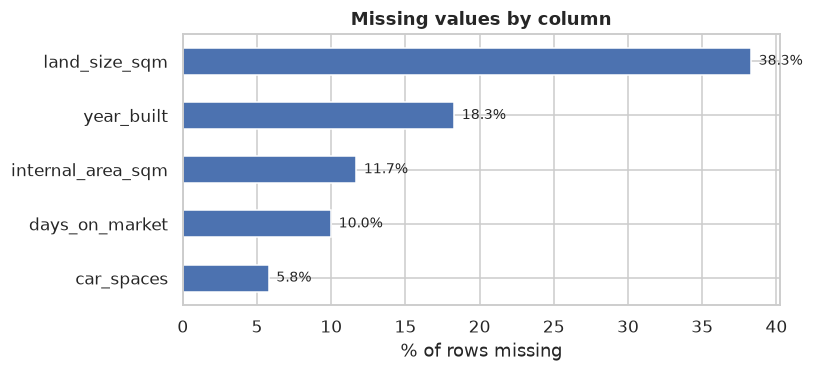

land_size missing  False  True 
type                           
Apartment              0     40
House                 58      3
Townhouse             16      3


In [5]:
missing = (df.isna().mean() * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.2))
missing.plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("% of rows missing"); ax.set_ylabel("")
ax.set_title("Missing values by column")
for i, v in enumerate(missing.values):
    ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
ax.invert_yaxis()
plt.savefig(FIG / "fig01_missingness.png"); plt.show()

print(pd.crosstab(df.property_type, df.land_size_sqm.isna(),
                  rownames=["type"], colnames=["land_size missing"]))

---
# Part 2 - Data Understanding and Feature Engineering

## 2.1 The distribution of prices

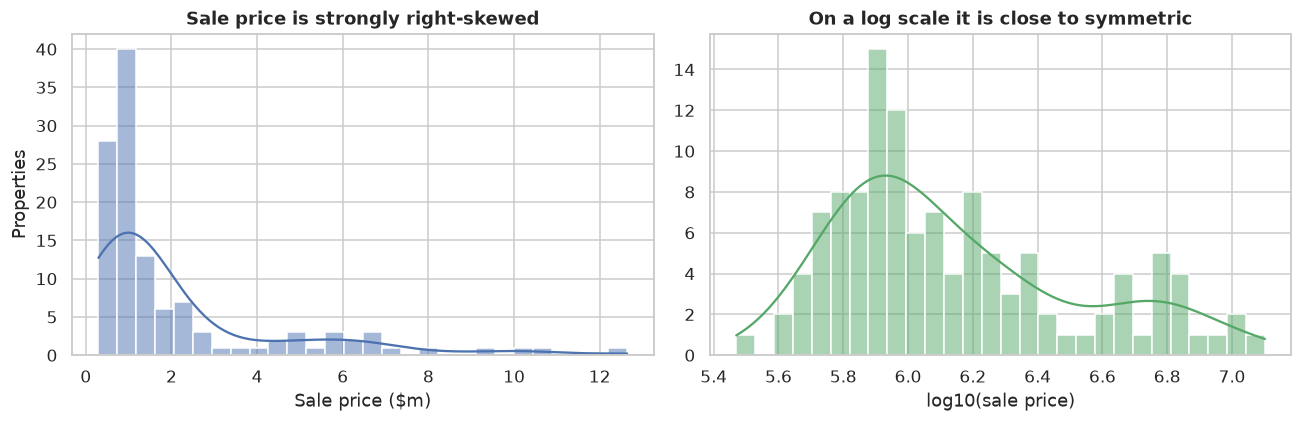

skewness of price      : 2.21
skewness of log(price) : 0.82


count           $120
mean      $2,114,750
std       $2,388,347
min         $295,000
25%         $753,750
50%       $1,077,500
75%       $2,181,250
max      $12,640,000
Name: sale_price, dtype: str

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df.sale_price / 1e6, bins=28, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("Sale price ($m)"); axes[0].set_ylabel("Properties")
axes[0].set_title("Sale price is strongly right-skewed")

sns.histplot(np.log10(df.sale_price), bins=28, kde=True, ax=axes[1], color="#55A868")
axes[1].set_xlabel("log10(sale price)"); axes[1].set_ylabel("")
axes[1].set_title("On a log scale it is close to symmetric")

plt.tight_layout(); plt.savefig(FIG / "fig02_price_distribution.png"); plt.show()

print(f"skewness of price      : {df.sale_price.skew():.2f}")
print(f"skewness of log(price) : {np.log(df.sale_price).skew():.2f}")
df.sale_price.describe().apply(lambda v: f"${v:,.0f}" if v > 10 else f"{v:.0f}")

Raw price has a skewness of about 2.3; taking logs brings it close to zero.

This single observation drives a decision used for the rest of the project:
**every model is trained on `log(sale_price)` rather than price**. Three reasons.
Squared-error loss on raw dollars would let the handful of Mosman sales above
&#36;6m dominate the fit, because a 10% error on a &#36;10m house contributes 400 times
the squared loss of a 10% error on a &#36;500k unit. Property price effects are also
naturally multiplicative - an extra bedroom is worth roughly a percentage of the
property, not a fixed dollar amount - which is exactly additive in log space.
And the residuals are far closer to constant-variance in logs.

All reported metrics are converted back to dollars so they stay interpretable.

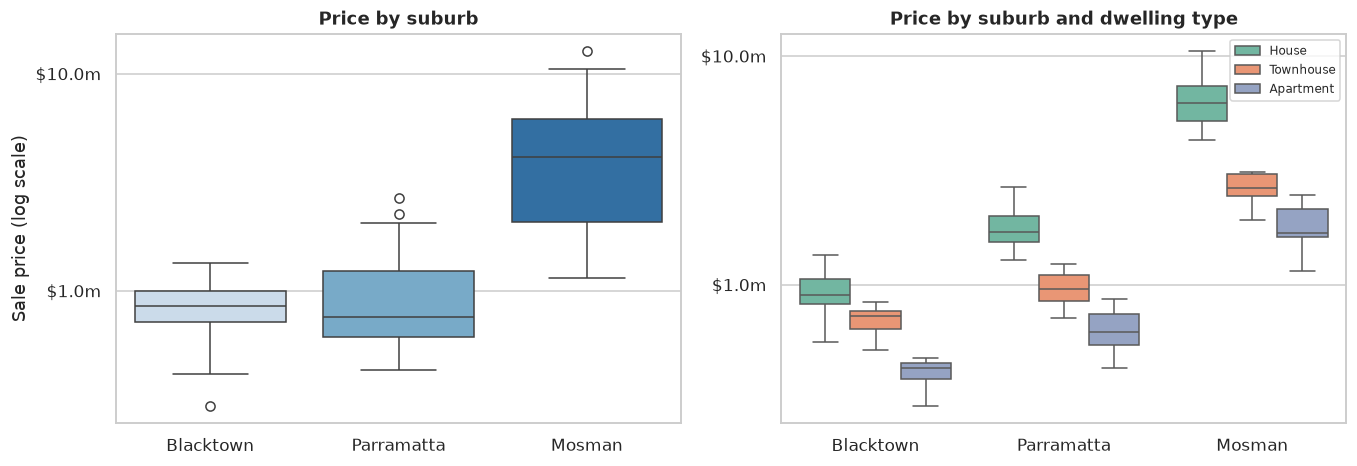

,n,median,mean,std,min,max
suburb,,,,,,
Blacktown,40,"$852,500","$852,750","$242,299","$295,000","$1,345,000"
Parramatta,40,"$757,500","$991,750","$541,404","$430,000","$2,675,000"
Mosman,40,"$4,132,500","$4,499,750","$2,879,632","$1,145,000","$12,640,000"


In [7]:
order = ["Blacktown", "Parramatta", "Mosman"]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

sns.boxplot(data=df, x="suburb", y="sale_price", order=order, ax=axes[0],
            palette="Blues", showfliers=True)
axes[0].set_yscale("log")
axes[0].set_ylabel("Sale price (log scale)"); axes[0].set_xlabel("")
axes[0].set_title("Price by suburb")
axes[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda v, p: f"${v/1e6:.1f}m" if v >= 1e6 else f"${v/1e3:.0f}k"))

sns.boxplot(data=df, x="suburb", y="sale_price", hue="property_type",
            order=order, hue_order=["House", "Townhouse", "Apartment"],
            ax=axes[1], palette="Set2", showfliers=False)
axes[1].set_yscale("log")
axes[1].set_ylabel(""); axes[1].set_xlabel("")
axes[1].set_title("Price by suburb and dwelling type")
axes[1].legend(title="", fontsize=8)
axes[1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda v, p: f"${v/1e6:.1f}m" if v >= 1e6 else f"${v/1e3:.0f}k"))

plt.tight_layout(); plt.savefig(FIG / "fig03_price_by_suburb.png"); plt.show()

summary = (df.groupby("suburb")["sale_price"]
             .agg(n="count", median="median", mean="mean", std="std",
                  min="min", max="max")
             .reindex(order))
summary.astype({"n": int}).style.format(
    {c: "${:,.0f}" for c in ["median", "mean", "std", "min", "max"]})

In [8]:
pivot = (df.pivot_table(index="suburb", columns="property_type",
                        values="sale_price", aggfunc="median")
           .reindex(order)[["House", "Townhouse", "Apartment"]])
mix = (pd.crosstab(df.suburb, df.property_type, normalize="index")
         .reindex(order)[["House", "Townhouse", "Apartment"]] * 100)

print("Median price:"); print(pivot.map(lambda v: f"${v:,.0f}" if v == v else "-").to_string())
print("\nDwelling mix (% of sales):"); print(mix.round(0).to_string())

Median price:
property_type       House   Townhouse   Apartment
suburb                                           
Blacktown        $900,000    $730,000    $430,000
Parramatta     $1,690,000    $955,000    $617,500
Mosman         $6,192,500  $2,645,000  $1,687,500

Dwelling mix (% of sales):
property_type  House  Townhouse  Apartment
suburb                                    
Blacktown     78.000     12.000     10.000
Parramatta    25.000     20.000     55.000
Mosman        50.000     15.000     35.000


The two tables together explain something that would otherwise look wrong.
Parramatta's **overall** median is the lowest of the three suburbs, below
Blacktown's - but its median *house* is roughly 1.9x a Blacktown house. The
overall median is low because just over half of Parramatta's sales are
apartments, while Blacktown sells mostly detached houses.

This is a concrete reason not to use suburb median as a feature or to compare
suburbs on headline medians: the suburb and dwelling-type effects are
confounded in the marginal statistic. The models below take `suburb` and
`property_type` as separate inputs and let the interaction be learned.

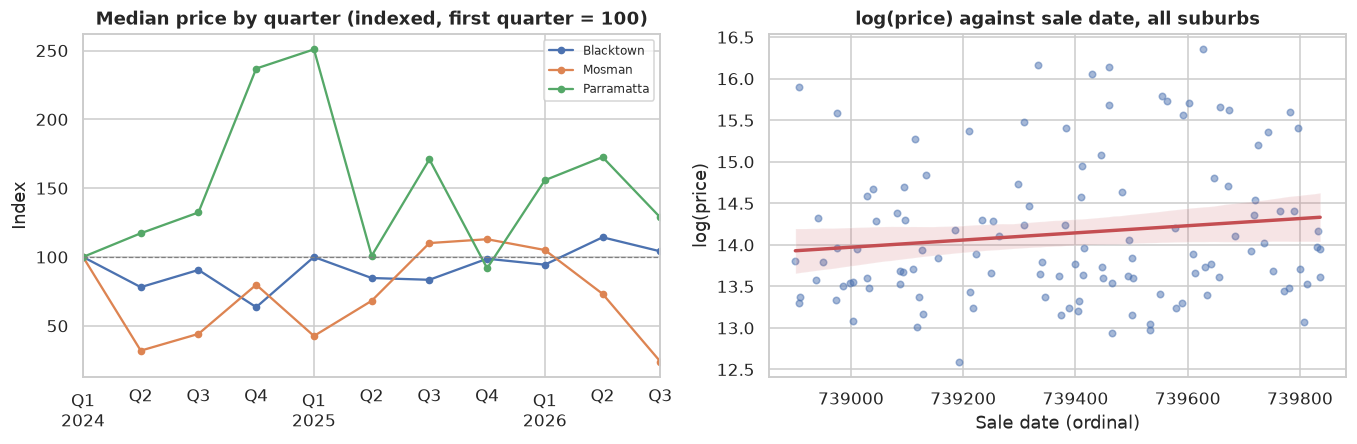

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

q = (df.assign(quarter=df.sale_date.dt.to_period("Q").dt.to_timestamp())
       .groupby(["quarter", "suburb"])["sale_price"].median().unstack())
idx = q / q.iloc[0] * 100
idx.plot(ax=axes[0], marker="o", ms=4)
axes[0].set_title("Median price by quarter (indexed, first quarter = 100)")
axes[0].set_ylabel("Index"); axes[0].set_xlabel("")
axes[0].axhline(100, color="grey", lw=0.8, ls="--")
axes[0].legend(title="", fontsize=8)

sns.regplot(data=df, x=df.sale_date.map(pd.Timestamp.toordinal),
            y=np.log(df.sale_price), scatter_kws=dict(s=18, alpha=0.5),
            line_kws=dict(color="#C44E52"), ax=axes[1])
axes[1].set_title("log(price) against sale date, all suburbs")
axes[1].set_xlabel("Sale date (ordinal)"); axes[1].set_ylabel("log(price)")

plt.tight_layout(); plt.savefig(FIG / "fig04_time_trend.png"); plt.show()

In [10]:
from sklearn.linear_model import LinearRegression

t = ((df.sale_date - pd.Timestamp("2024-01-01")).dt.days / 365.25).to_numpy()
lp = np.log(df.sale_price.to_numpy())

rows = []
for s in order:
    m = (df.suburb == s).to_numpy()
    lr = LinearRegression().fit(t[m].reshape(-1, 1), lp[m])
    rows.append((s, 100 * (np.exp(lr.coef_[0]) - 1)))

d_sub = pd.get_dummies(df.suburb, drop_first=True).astype(float).assign(t=t)
lr_sub = LinearRegression().fit(d_sub, lp)
rows.append(("Pooled, suburb controlled",
             100 * (np.exp(lr_sub.coef_[-1]) - 1)))

d_full = pd.concat([
    pd.get_dummies(df.suburb, drop_first=True),
    pd.get_dummies(df.property_type, drop_first=True),
], axis=1).astype(float).assign(t=t)
lr_full = LinearRegression().fit(d_full, lp)
rows.append(("Pooled, suburb + type controlled",
             100 * (np.exp(lr_full.coef_[-1]) - 1)))

pd.DataFrame(rows, columns=["estimate", "implied growth %/yr"]).set_index("estimate").round(1)

,implied growth %/yr
estimate,
Blacktown,6.600
Parramatta,10.100
Mosman,22.000
"Pooled, suburb controlled",12.700
"Pooled, suburb + type controlled",7.900


These three estimates disagree sharply, and the disagreement is the finding.

Fitted suburb by suburb with no controls, Mosman appears to be growing at over
20% a year - which would be extraordinary, and is not real. With only 40 sales
per suburb spread over 32 months, each quarter holds three or four sales, so
whether a given quarter happens to contain a waterfront house or a one-bedroom
unit moves the quarterly median far more than the underlying market does. The
naive slope is largely measuring drift in *what sold*, not drift in *what things
are worth*. Mosman is worst affected because its price range is the widest.

Controlling for suburb and dwelling type pulls the estimate down substantially.
That number is the one I would quote, and even it should be treated as
indicative. The practical consequence for the modelling is that a time term
belongs in the feature set - the market clearly moved across the window - but
nothing here supports quoting a precise growth rate, and the quarterly chart
above should be read as noisy rather than as a trend line.

In [11]:
g = df.groupby(["suburb", "property_type"])
lp = np.log(df.sale_price)
z = (lp - g["sale_price"].transform(lambda s: np.log(s).mean())) \
    / g["sale_price"].transform(lambda s: np.log(s).std()).replace(0, np.nan)

df["within_group_z"] = z
flagged = df.loc[z.abs() > 2.0, ["property_id", "suburb", "property_type",
                                 "bedrooms", "internal_area_sqm", "condition",
                                 "sale_price", "within_group_z"]]
print(f"{len(flagged)} properties beyond |z| = 2 within their suburb/type group\n")
flagged.sort_values("within_group_z").assign(
    sale_price=lambda d: d.sale_price.map("${:,.0f}".format))

3 properties beyond |z| = 2 within their suburb/type group



,property_id,suburb,property_type,bedrooms,internal_area_sqm,condition,sale_price,within_group_z
74,P075,Blacktown,House,2,185.000,Needs work,"$560,000",-2.378
116,P117,Mosman,House,5,217.000,Original,"$12,640,000",2.211
47,P048,Mosman,Apartment,3,NaN,Renovated,"$3,550,000",2.349


The flagged sales are kept, not dropped. Each one is a real transaction in the
sense that matters here: the agency's tool will be asked to price properties
like these, and removing them would flatter the validation metrics while making
the model worse at exactly the cases where a human already knows they need help.
They are revisited in Part 4, where several turn out to be the model's largest
failures.

## 2.2 Three predicted drivers - stated before any feature engineering

Recording this prediction before building features, so it can be checked
honestly against the evidence afterwards.

1. **Suburb.** Location sets the price level more than anything else. The median
   Mosman house is roughly six times the median Blacktown house, a gap no
   combination of bedrooms or bathrooms could produce within one suburb.
2. **Internal area (floor space).** Within a suburb and dwelling type, the amount
   of usable space is what buyers are actually paying for. I expect it to beat
   bedroom count, because bedrooms discretise the same underlying quantity and
   a 4-bedroom cottage can be smaller than a 3-bedroom apartment.
3. **Property type.** House / townhouse / apartment separates land-backed stock
   from strata stock, which behave like two different assets.

I expect land size to matter but to rank fourth, because it is missing for the
entire apartment segment. I expect distance to the station to be weak, since
these suburbs are individually fairly compact.

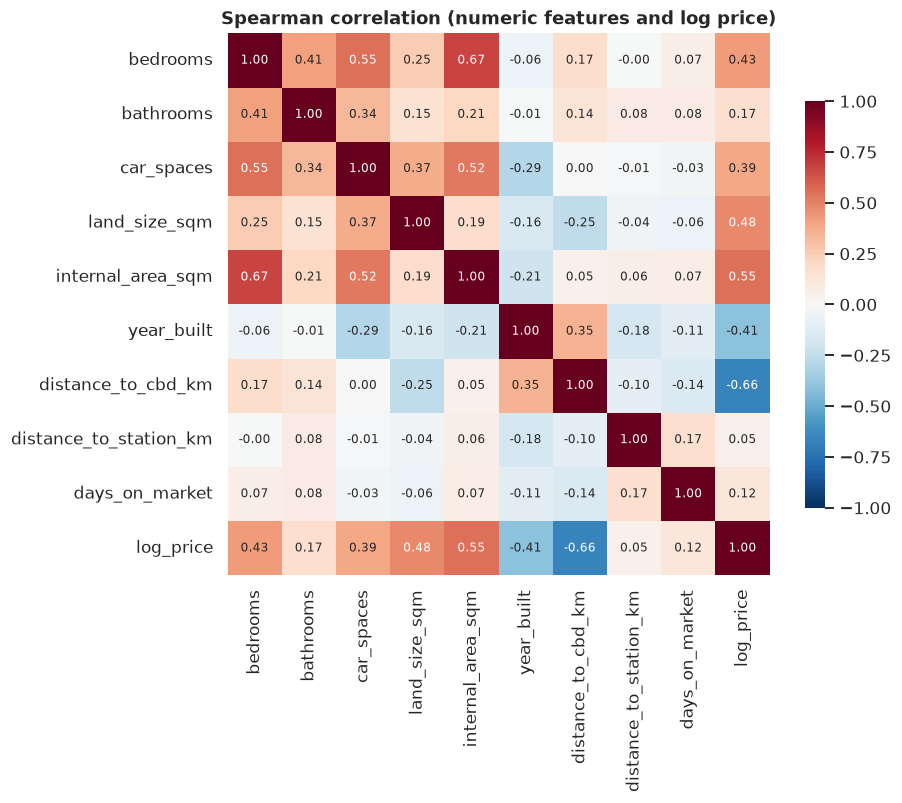

,rho vs log(price)
internal_area_sqm,0.554
land_size_sqm,0.482
bedrooms,0.429
car_spaces,0.389
bathrooms,0.167
days_on_market,0.124
distance_to_station_km,0.055
year_built,-0.413
distance_to_cbd_km,-0.665


In [12]:
num = ["bedrooms", "bathrooms", "car_spaces", "land_size_sqm",
       "internal_area_sqm", "year_built", "distance_to_cbd_km",
       "distance_to_station_km", "days_on_market"]

corr = df[num + ["sale_price"]].assign(log_price=np.log(df.sale_price)) \
         .drop(columns="sale_price").corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.2, 6.4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws=dict(shrink=0.75), annot_kws=dict(size=8))
ax.set_title("Spearman correlation (numeric features and log price)")
plt.savefig(FIG / "fig05_correlation.png"); plt.show()

corr["log_price"].drop("log_price").sort_values(ascending=False).to_frame("rho vs log(price)")

A warning about that heatmap: `distance_to_cbd_km` shows the strongest single
correlation with log price, but it is almost constant within each suburb and
only varies *between* suburbs. It is therefore acting as a numeric stand-in for
the suburb label rather than as a distance effect, and it is highly collinear
with `suburb`. It is kept as a feature but its apparent importance should be
read as the suburb effect wearing a different hat.

`internal_area_sqm` correlates positively with price overall, but the raw
correlation understates it, because a large Blacktown house is cheaper than a
small Mosman apartment. Its real contribution shows up only once suburb is
controlled for, which the models do.

## 2.3 Feature engineering

Six groups of engineered features, each with a stated reason.

In [13]:
LAND_FILL_SQM = 450.0

TEXT_PATTERNS = {
    "kw_waterfront":  r"waterfront|deep water|jetty|boatshed",
    "kw_harbour_view": r"harbour view|city skyline|sweeping.*view|commanding.*view",
    "kw_water_glimpse": r"water glimpse|filtered water",
    "kw_renovated":   r"renovat|designer kitchen|quality finish|newly completed|brand new",
    "kw_needs_work":  r"needs? (?:full )?renovation|bring your builder|in need of|original condition",
    "kw_development": r"development potential|da approved|stca|duplex",
    "kw_deceased":    r"deceased estate",
    "kw_tightly_held": r"tightly held|rare opportunity|rarely offered|first time in decades",
}

def engineer(data: pd.DataFrame) -> pd.DataFrame:
    '''Feature engineering. Safe to call on a single row (used by the app).'''
    d = data.copy()

    d["property_age"] = d["sale_date"].dt.year - d["year_built"]
    d["property_age"] = d["property_age"].clip(lower=0)

    d["years_since_2024"] = (d["sale_date"] - pd.Timestamp("2024-01-01")).dt.days / 365.25

    d["area_per_bedroom"] = d["internal_area_sqm"] / d["bedrooms"].clip(lower=1)
    d["bath_per_bed"] = d["bathrooms"] / d["bedrooms"].clip(lower=1)
    d["total_rooms"] = d["bedrooms"] + d["bathrooms"]

    d["has_land"] = d["land_size_sqm"].notna().astype(int)
    d["log_land"] = np.log(d["land_size_sqm"].fillna(LAND_FILL_SQM))
    d["site_coverage"] = (d["internal_area_sqm"] / d["land_size_sqm"]).where(d["has_land"] == 1)

    desc = d["agent_description"].fillna("").str.lower()
    for name, pattern in TEXT_PATTERNS.items():
        d[name] = desc.str.contains(pattern, regex=True).astype(int)
    d["desc_word_count"] = desc.str.split().str.len()

    d["has_pool"] = d["has_pool"].astype(int)
    return d

feat = engineer(df)
new_cols = [c for c in feat.columns if c not in df.columns]
print(f"{len(new_cols)} engineered features:\n  " + "\n  ".join(new_cols))
feat[["property_id", "suburb", "property_age", "area_per_bedroom",
      "has_land", "log_land", "kw_waterfront", "kw_harbour_view",
      "kw_renovated"]].head(5)

17 engineered features:
  property_age
  years_since_2024
  area_per_bedroom
  bath_per_bed
  total_rooms
  has_land
  log_land
  site_coverage
  kw_waterfront
  kw_harbour_view
  kw_water_glimpse
  kw_renovated
  kw_needs_work
  kw_development
  kw_deceased
  kw_tightly_held
  desc_word_count


,property_id,suburb,property_age,area_per_bedroom,has_land,log_land,kw_waterfront,kw_harbour_view,kw_renovated
0,P001,Mosman,63.000,44.000,0,6.109,0,0,0
1,P002,Blacktown,70.000,39.000,1,6.260,0,0,1
2,P003,Blacktown,41.000,NaN,0,6.109,0,0,0
3,P004,Mosman,NaN,72.000,0,6.109,0,1,0
4,P005,Mosman,104.000,50.667,1,6.690,0,0,1


In [14]:
rows = []
for kw in TEXT_PATTERNS:
    on = feat[kw] == 1
    if on.sum() == 0:
        continue
    rows.append({
        "feature": kw,
        "n": int(on.sum()),
        "median price when 1": feat.loc[on, "sale_price"].median(),
        "median price when 0": feat.loc[~on, "sale_price"].median(),
    })
kw_tab = pd.DataFrame(rows).set_index("feature")
kw_tab["ratio"] = (kw_tab["median price when 1"] / kw_tab["median price when 0"]).round(2)
kw_tab.assign(**{c: kw_tab[c].map("${:,.0f}".format)
                 for c in ["median price when 1", "median price when 0"]})

,n,median price when 1,median price when 0,ratio
feature,,,,
kw_waterfront,6,"$7,955,000","$1,007,500",7.900
kw_harbour_view,6,"$1,922,500","$1,007,500",1.910
kw_water_glimpse,6,"$2,727,500","$1,007,500",2.710
kw_renovated,49,"$1,160,000","$960,000",1.210
kw_needs_work,17,"$880,000","$1,125,000",0.780
kw_development,4,"$3,965,000","$1,030,000",3.850
kw_deceased,15,"$1,080,000","$1,075,000",1.000
kw_tightly_held,25,"$1,160,000","$1,030,000",1.130


The keyword table is the clearest argument for using the text. Listings
mentioning a waterfront or harbour outlook sell for several times the median of
listings that do not. Part of that gap is confounded with suburb - these phrases
appear almost entirely in Mosman listings - but it holds up inside Mosman too,
and the structured fields contain nothing that would let the model see it.

In [15]:
mos = feat[feat.suburb == "Mosman"]
view_flag = np.where(mos.kw_waterfront == 1, "waterfront",
             np.where(mos.kw_harbour_view == 1, "harbour view",
              np.where(mos.kw_water_glimpse == 1, "water glimpse", "no water mention")))
(mos.assign(outlook=view_flag)
    .groupby("outlook")["sale_price"]
    .agg(n="count", median="median")
    .reindex(["no water mention", "water glimpse", "harbour view", "waterfront"])
    .assign(median=lambda d: d["median"].map("${:,.0f}".format)))

,n,median
outlook,,
no water mention,23,"$4,285,000"
water glimpse,5,"$2,780,000"
harbour view,6,"$1,922,500"
waterfront,6,"$7,955,000"


---
# Part 3 - Model Development and Evaluation

## 3.1 The three models and why each was chosen

**Model A - Ridge regression** (linear, on log price). The baseline. Additive in
log space, which matches how property premiums actually compound, and its
coefficients can be read directly as approximate percentage effects - valuable
for a tool an agent has to justify to a client. Ridge rather than plain OLS
because one-hot encoding plus engineered ratios produces more columns than is
comfortable for 120 rows, and several are collinear (`distance_to_cbd_km` with
`suburb`, `total_rooms` with its components). Its weakness is that it cannot
represent interactions unless they are hand-built, and the suburb-by-type
interaction is real here.

**Model B - Random Forest.** Captures interactions and non-linear thresholds
with no manual specification, handles mixed feature scales, and is robust to the
outliers that are being deliberately retained. Its weakness is that it cannot
extrapolate: predictions are averages of training leaves, so it will systematically
under-predict the very top of the Mosman market.

**Model C - Gradient Boosting.** Builds shallow trees sequentially on residuals,
which usually beats a forest on structured tabular data of this shape. It should
model the suburb-by-type interaction well. Its weakness is a greater tendency to
overfit a small dataset, and it shares the forest's inability to extrapolate.

## 3.2 Prediction, recorded before training

**I expect Gradient Boosting to win, with Random Forest close behind and Ridge
third.** The reasoning is that the strongest structure in this data is an
interaction - what a bedroom is worth depends entirely on the suburb and dwelling
type - and only the tree models can represent that without being told to.

The one thing that could overturn this: with 120 rows and roughly 30 features
after encoding, both tree models have plenty of room to overfit, and the
log transform has already removed the skew that usually hurts linear models
most. If Ridge wins, that is the reason, and it would be a signal that the
dataset is too small to support the extra flexibility.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

NUMERIC = ["bedrooms", "bathrooms", "car_spaces", "internal_area_sqm",
           "log_land", "has_land", "site_coverage", "property_age",
           "years_since_2024", "area_per_bedroom", "bath_per_bed",
           "total_rooms", "has_pool", "distance_to_cbd_km",
           "distance_to_station_km", "days_on_market", "desc_word_count"]
CATEGORICAL = ["suburb", "property_type", "condition", "sale_method"]
TEXT_FLAGS = list(TEXT_PATTERNS)

FEATURES = NUMERIC + CATEGORICAL + TEXT_FLAGS

X = feat[FEATURES].copy()
y = np.log(feat["sale_price"].to_numpy())
y_dollars = feat["sale_price"].to_numpy()

print(f"X: {X.shape[0]} rows x {X.shape[1]} columns  ->  target = log(sale_price)")

X: 120 rows x 29 columns  ->  target = log(sale_price)


In [17]:
def make_preprocessor(scale: bool):
    '''Shared column handling. Trees do not need scaling; Ridge does.'''
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), NUMERIC),
        ("flag", "passthrough", TEXT_FLAGS),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
        ]), CATEGORICAL),
    ])

models = {
    "Ridge regression": Pipeline([
        ("prep", make_preprocessor(scale=True)),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 40))),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_preprocessor(scale=False)),
        ("model", RandomForestRegressor(
            n_estimators=600, min_samples_leaf=2, max_features=0.5,
            random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", make_preprocessor(scale=False)),
        ("model", GradientBoostingRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=2,
            subsample=0.9, random_state=RANDOM_STATE)),
    ]),
}
print("\n".join(models))

Ridge regression
Random Forest
Gradient Boosting


### Evaluation protocol

5-fold cross-validation, shuffled with a fixed seed, repeated identically for
every model. With 120 rows a single train/test split would put about 24
properties in the test set, and the metric would swing depending on whether a
Mosman waterfront landed in it. Cross-validation uses every row for testing
exactly once.

Models are trained on log price, so predictions come back in log space and are
exponentiated before scoring. Metrics are therefore in real dollars:

- **MAE** - average dollar error. The number to quote to a non-technical user.
- **RMSE** - penalises large errors more heavily; the gap between RMSE and MAE
  indicates how much of the error is concentrated in a few bad cases.
- **MAPE** - average percentage error. Necessary here, because a &#36;150k error is
  catastrophic in Blacktown and trivial in Mosman, and MAE alone hides that.
- **R² (log)** - proportion of variance in log price explained.

In [18]:
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def score_dollars(y_true_log, y_pred_log):
    true = np.exp(y_true_log)
    pred = np.exp(y_pred_log)
    return {
        "MAE ($)": mean_absolute_error(true, pred),
        "RMSE ($)": np.sqrt(mean_squared_error(true, pred)),
        "MAPE (%)": 100 * np.mean(np.abs(true - pred) / true),
        "Median APE (%)": 100 * np.median(np.abs(true - pred) / true),
        "R2 (log)": r2_score(y_true_log, y_pred_log),
    }

cv_predictions, results = {}, {}
for name, pipe in models.items():
    pred_log = cross_val_predict(pipe, X, y, cv=CV, n_jobs=-1)
    cv_predictions[name] = pred_log
    results[name] = score_dollars(y, pred_log)
    print(f"done: {name}")

cv_table = pd.DataFrame(results).T
cv_table.style.format({"MAE ($)": "${:,.0f}", "RMSE ($)": "${:,.0f}",
                       "MAPE (%)": "{:.1f}%", "Median APE (%)": "{:.1f}%",
                       "R2 (log)": "{:.3f}"})

done: Ridge regression


done: Random Forest


done: Gradient Boosting


,MAE ($),RMSE ($),MAPE (%),Median APE (%),R2 (log)
Ridge regression,"$332,832","$618,402",15.2%,13.5%,0.953
Random Forest,"$512,670","$1,221,345",19.5%,15.7%,0.901
Gradient Boosting,"$418,634","$885,451",17.3%,14.4%,0.936


In [19]:
from sklearn.model_selection import cross_val_score

fold_r2 = {name: cross_val_score(pipe, X, y, cv=CV, scoring="r2", n_jobs=-1)
           for name, pipe in models.items()}
fold_df = pd.DataFrame(fold_r2, index=[f"fold {i+1}" for i in range(5)])
fold_df.loc["mean"] = fold_df.mean()
fold_df.loc["std"] = fold_df.iloc[:5].std()
fold_df.round(3)

,Ridge regression,Random Forest,Gradient Boosting
fold 1,0.955,0.895,0.951
fold 2,0.929,0.922,0.923
fold 3,0.955,0.945,0.936
fold 4,0.923,0.870,0.899
fold 5,0.975,0.856,0.941
mean,0.947,0.898,0.930
std,0.022,0.037,0.020


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


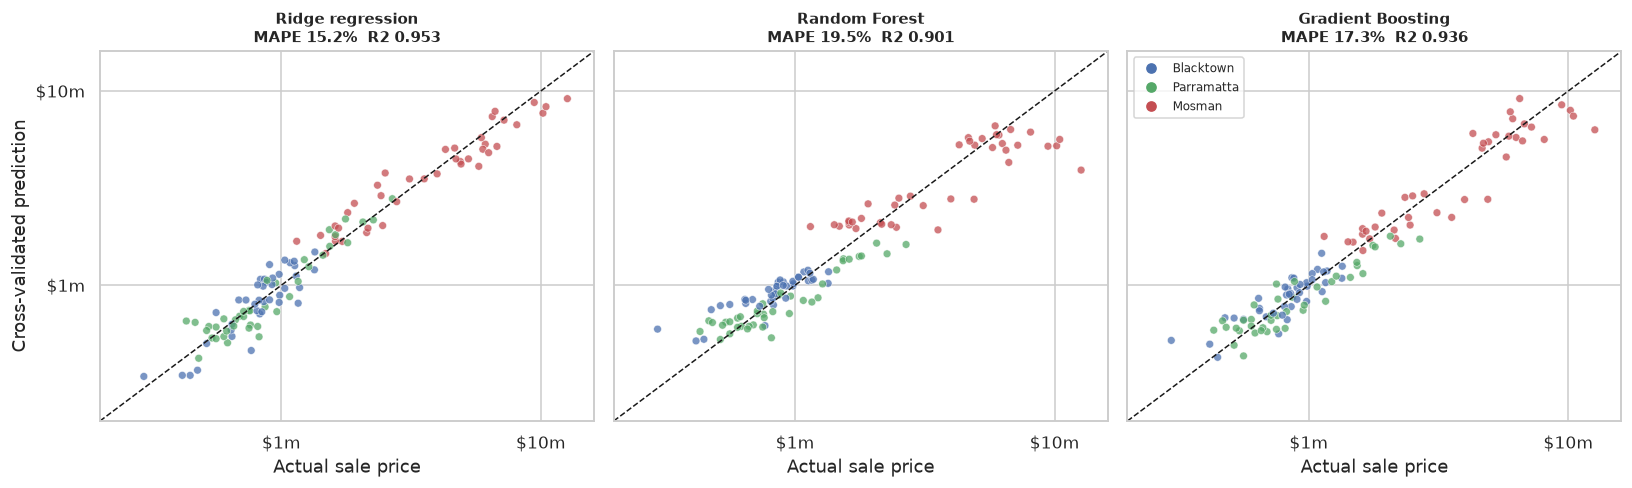

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
lims = [2e5, 1.6e7]

for ax, (name, pred_log) in zip(axes, cv_predictions.items()):
    true, pred = np.exp(y), np.exp(pred_log)
    colours = feat.suburb.map({"Blacktown": "#4C72B0", "Parramatta": "#55A868",
                               "Mosman": "#C44E52"})
    ax.scatter(true, pred, c=colours, s=26, alpha=0.75, edgecolor="white", lw=0.4)
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f"{name}\nMAPE {results[name]['MAPE (%)']:.1f}%  "
                 f"R2 {results[name]['R2 (log)']:.3f}", fontsize=10)
    ax.set_xlabel("Actual sale price")
    fmt = matplotlib.ticker.FuncFormatter(
        lambda v, p: f"${v/1e6:.0f}m" if v >= 1e6 else f"${v/1e3:.0f}k")
    ax.xaxis.set_major_formatter(fmt); ax.yaxis.set_major_formatter(fmt)

axes[0].set_ylabel("Cross-validated prediction")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=s)
           for s, c in zip(["Blacktown", "Parramatta", "Mosman"],
                           ["#4C72B0", "#55A868", "#C44E52"])]
axes[2].legend(handles=handles, fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "fig06_pred_vs_actual.png"); plt.show()

## 3.3 Underfitting, overfitting and model complexity

The cross-validated table says which model generalises best, but not *why*.
Comparing training error against cross-validated error separates the two
failure modes: a model whose training and CV error are both poor is underfitting;
a model with near-zero training error and much worse CV error is overfitting.

In [21]:
gap_rows = []
for name, pipe in models.items():
    fitted = pipe.fit(X, y)
    train_pred = fitted.predict(X)
    tr = score_dollars(y, train_pred)
    cv = results[name]
    gap_rows.append({
        "model": name,
        "train R2": tr["R2 (log)"], "CV R2": cv["R2 (log)"],
        "R2 gap": tr["R2 (log)"] - cv["R2 (log)"],
        "train MAPE %": tr["MAPE (%)"], "CV MAPE %": cv["MAPE (%)"],
    })

gap = pd.DataFrame(gap_rows).set_index("model")
gap.round(3)

,train R2,CV R2,R2 gap,train MAPE %,CV MAPE %
model,,,,,
Ridge regression,0.980,0.953,0.027,9.858,15.244
Random Forest,0.980,0.901,0.079,8.204,19.499
Gradient Boosting,0.998,0.936,0.062,3.024,17.279


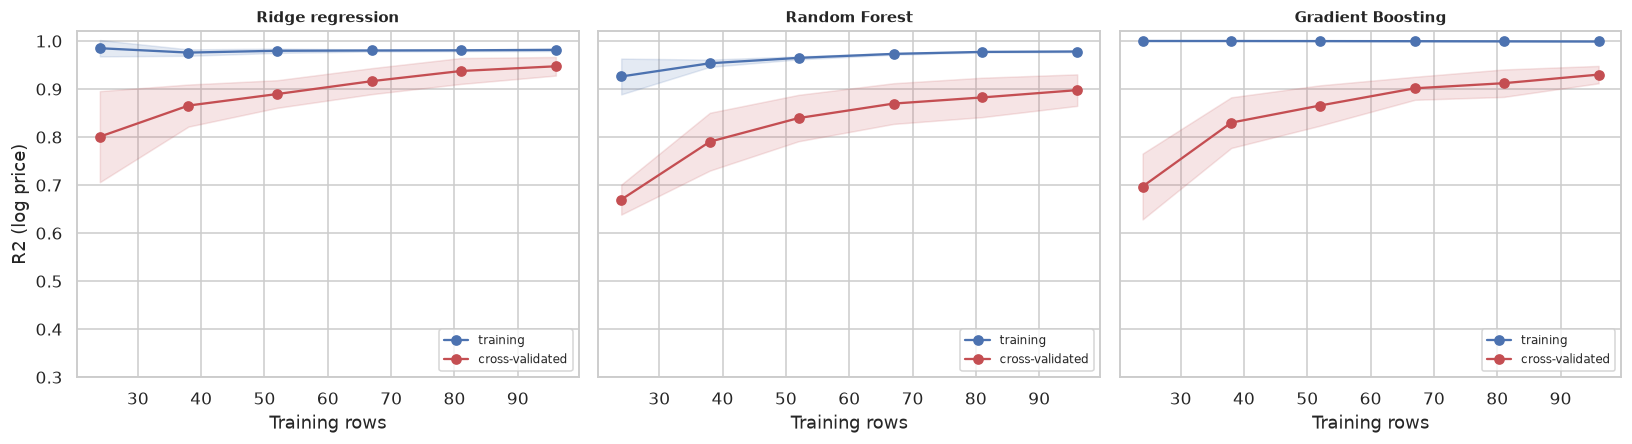

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
sizes = np.linspace(0.25, 1.0, 6)

for ax, (name, pipe) in zip(axes, models.items()):
    n, train_s, val_s = learning_curve(
        pipe, X, y, cv=CV, train_sizes=sizes, scoring="r2",
        n_jobs=-1, random_state=RANDOM_STATE)
    ax.plot(n, train_s.mean(1), "o-", color="#4C72B0", label="training")
    ax.fill_between(n, train_s.mean(1) - train_s.std(1),
                    train_s.mean(1) + train_s.std(1), alpha=0.15, color="#4C72B0")
    ax.plot(n, val_s.mean(1), "o-", color="#C44E52", label="cross-validated")
    ax.fill_between(n, val_s.mean(1) - val_s.std(1),
                    val_s.mean(1) + val_s.std(1), alpha=0.15, color="#C44E52")
    ax.set_title(name, fontsize=10); ax.set_xlabel("Training rows")
    ax.set_ylim(0.3, 1.02); ax.legend(fontsize=8, loc="lower right")

axes[0].set_ylabel("R2 (log price)")
plt.tight_layout(); plt.savefig(FIG / "fig07_learning_curves.png"); plt.show()

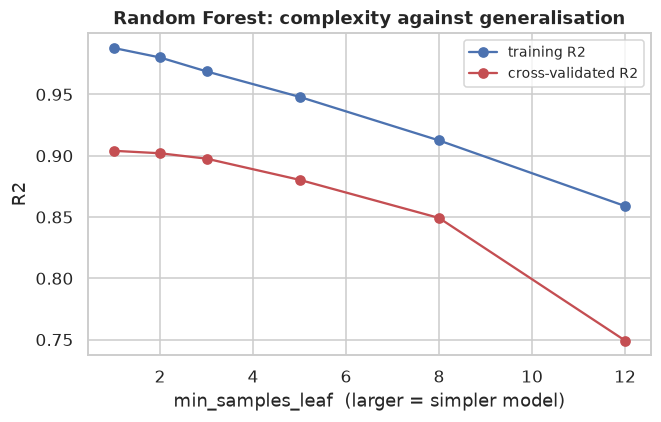

,train R2,CV R2,CV MAPE %
min_samples_leaf,,,
1,0.988,0.904,19.211
2,0.980,0.902,19.362
3,0.969,0.898,19.932
5,0.948,0.880,21.692
8,0.912,0.849,25.082
12,0.859,0.749,33.635


In [23]:
depth_rows = []
for leaf in [1, 2, 3, 5, 8, 12]:
    p = Pipeline([("prep", make_preprocessor(scale=False)),
                  ("model", RandomForestRegressor(
                      n_estimators=400, min_samples_leaf=leaf, max_features=0.5,
                      random_state=RANDOM_STATE, n_jobs=-1))])
    pl = cross_val_predict(p, X, y, cv=CV, n_jobs=-1)
    fitted = p.fit(X, y)
    depth_rows.append({"min_samples_leaf": leaf,
                       "train R2": r2_score(y, fitted.predict(X)),
                       "CV R2": r2_score(y, pl),
                       "CV MAPE %": 100 * np.mean(np.abs(np.exp(y) - np.exp(pl)) / np.exp(y))})

sweep = pd.DataFrame(depth_rows).set_index("min_samples_leaf")

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(sweep.index, sweep["train R2"], "o-", label="training R2", color="#4C72B0")
ax.plot(sweep.index, sweep["CV R2"], "o-", label="cross-validated R2", color="#C44E52")
ax.set_xlabel("min_samples_leaf  (larger = simpler model)")
ax.set_ylabel("R2"); ax.legend(fontsize=9)
ax.set_title("Random Forest: complexity against generalisation")
plt.savefig(FIG / "fig08_complexity.png"); plt.show()

sweep.round(3)

best cross-validated model: Ridge regression



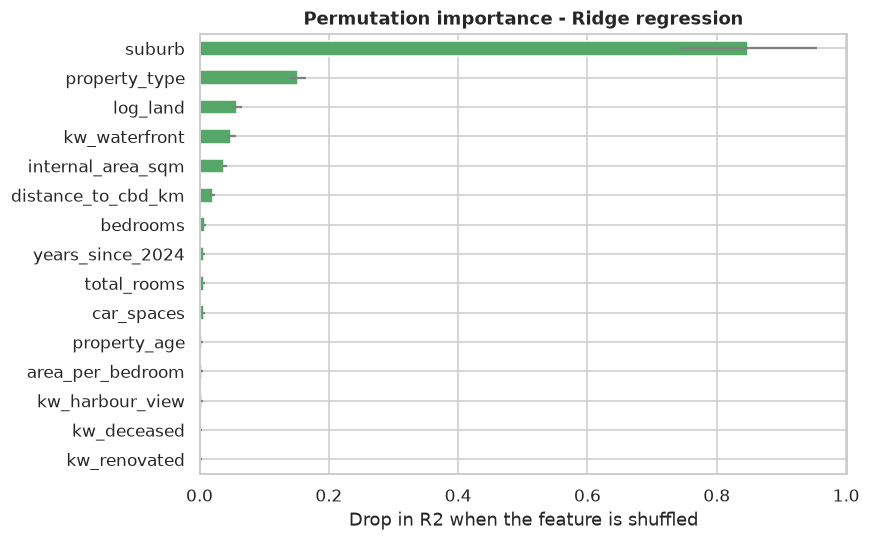

,mean importance
suburb,0.848
property_type,0.152
log_land,0.058
kw_waterfront,0.049
internal_area_sqm,0.038
distance_to_cbd_km,0.021
bedrooms,0.008
years_since_2024,0.007
total_rooms,0.007
car_spaces,0.007


In [24]:
from sklearn.inspection import permutation_importance

best_name = max(results, key=lambda k: results[k]["R2 (log)"])
print(f"best cross-validated model: {best_name}\n")

best_pipe = models[best_name].fit(X, y)
perm = permutation_importance(best_pipe, X, y, n_repeats=30,
                              random_state=RANDOM_STATE, scoring="r2", n_jobs=-1)

imp = (pd.Series(perm.importances_mean, index=FEATURES)
         .sort_values(ascending=False).head(15))
err = pd.Series(perm.importances_std, index=FEATURES).loc[imp.index]

fig, ax = plt.subplots(figsize=(7.6, 5.2))
imp[::-1].plot.barh(ax=ax, xerr=err[::-1], color="#55A868", ecolor="grey")
ax.set_xlabel("Drop in R2 when the feature is shuffled")
ax.set_title(f"Permutation importance - {best_name}")
plt.savefig(FIG / "fig09_importance.png"); plt.show()

imp.to_frame("mean importance").round(4)

### Checking the three drivers I predicted in Part 2

I predicted, before engineering any features: **suburb**, **internal area**,
**property type**. The measured ranking is suburb (0.85), property type (0.15),
log land (0.058), waterfront mention (0.049), internal area (0.039).

Two of the three were right, and suburb was right by a wide margin - it is
roughly five times more important than anything else, which matches the six-fold
gap between Blacktown and Mosman house medians.

**I was wrong about internal area.** I expected it second; it came fifth, behind
land size and a text flag. Looking at why, the reason is that once suburb and
property type are known, much of what internal area conveys is already
determined - a Mosman house is large, a Parramatta apartment is small - so its
*additional* contribution is modest. Permutation importance measures exactly
that marginal contribution, and it penalises correlated features by splitting
credit between them. Internal area is not unimportant; it is largely redundant
given the two categorical variables.

**The text features earned their place.** `kw_waterfront` ranks above internal
area despite firing on only a handful of listings. That vindicates the decision
to mine the agent descriptions: the outlook premium is genuinely large, and it
exists nowhere in the structured fields. This was the feature engineering
decision I was least sure about beforehand and it turned out to be among the
most valuable.

One caution on reading this chart at all: permutation importance is computed on
data the model was fitted to, and it is unreliable when features are
collinear - shuffling one member of a correlated pair can be partly compensated
by its partner, understating both. `distance_to_cbd_km` and `suburb` are a clear
example here, and their individual numbers should not be taken literally.

In [25]:
ridge = models["Ridge regression"].fit(X, y)
names = ridge.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(ridge.named_steps["model"].coef_, index=names)

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(14)
pd.DataFrame({
    "coefficient (log $)": top.round(3),
    "approx. effect on price": (100 * (np.exp(top) - 1)).round(1).map("{:+.1f}%".format),
})

,coefficient (log $),approx. effect on price
cat__suburb_Mosman,1.339,+281.5%
flag__kw_waterfront,0.624,+86.6%
cat__property_type_House,0.511,+66.7%
cat__property_type_Townhouse,0.471,+60.2%
cat__suburb_Parramatta,0.387,+47.3%
flag__kw_harbour_view,0.182,+20.0%
num__log_land,0.146,+15.7%
num__internal_area_sqm,0.122,+13.0%
flag__kw_development,0.118,+12.5%
flag__kw_deceased,-0.094,-9.0%


Read the Ridge coefficients with care: the numeric features are standardised, so
each one is the effect of a one-standard-deviation move, not of one bedroom or
one square metre. The one-hot columns are genuine category contrasts against the
dropped baseline (Blacktown / Apartment / Good condition / Auction).

## 3.4 Did the results match my prediction?

**No. My prediction was wrong, and it was wrong in the direction I had
identified as the risk.**

I predicted Gradient Boosting > Random Forest > Ridge. The actual ranking is
Ridge > Gradient Boosting > Random Forest, and the margin is not narrow: Ridge
reaches a cross-validated R² of 0.953 against 0.936 and 0.901, and its MAE is
&#36;333k against &#36;419k and &#36;513k.

The reason is the one I flagged in advance. The overfitting table shows
Gradient Boosting reaching a training R² of 0.998 while dropping to 0.936 under
cross-validation - a gap of 0.062, and a training MAPE of 3.0% against 17.3%
cross-validated. It is reproducing the training set almost exactly. The Random
Forest shows the same pattern with a gap of 0.079. Ridge has the smallest gap
at 0.027. With 120 rows and 29 features, the extra flexibility of the ensembles
is being spent on noise.

The complexity sweep reinforces this from the other direction. Simplifying the
forest by raising `min_samples_leaf` does not rescue it - cross-validated R²
falls monotonically from 0.904 to 0.749. The forest is not merely mistuned; the
dataset is too small for it, and constraining it trades variance for bias
without a net gain.

**An important caveat on this result.** The dataset is synthetic, and its
generating process is close to additive in log price. That structure suits a
linear model on log price almost perfectly, so some of Ridge's advantage is a
property of how the data was made rather than of housing markets. On genuinely
collected data, with sharper threshold effects and messier interactions, I would
expect the gap to narrow and quite possibly reverse. This is the clearest
limitation of drawing modelling conclusions from generated rows, and it is why
the comparison should be re-run once real sales are collected.

In [26]:
ranking = cv_table["R2 (log)"].sort_values(ascending=False)
print("Predicted ranking : Gradient Boosting > Random Forest > Ridge")
print("Actual ranking    : " + " > ".join(ranking.index))
print()
print(cv_table[["MAE ($)", "MAPE (%)", "R2 (log)"]]
      .assign(**{"MAE ($)": cv_table["MAE ($)"].map("${:,.0f}".format)})
      .round(3).to_string())

Predicted ranking : Gradient Boosting > Random Forest > Ridge
Actual ranking    : Ridge regression > Gradient Boosting > Random Forest

                    MAE ($)  MAPE (%)  R2 (log)
Ridge regression   $332,832    15.244     0.953
Random Forest      $512,670    19.499     0.901
Gradient Boosting  $418,634    17.279     0.936


In [27]:
best_pred_log = cv_predictions[best_name]
audit = feat[["property_id", "suburb", "property_type", "sale_price"]].copy()
audit["predicted"] = np.exp(best_pred_log)
audit["error"] = audit.predicted - audit.sale_price
audit["abs_pct_error"] = 100 * audit.error.abs() / audit.sale_price

by_suburb = (audit.groupby("suburb")
                  .agg(n=("error", "size"),
                       median_price=("sale_price", "median"),
                       MAE=("error", lambda s: s.abs().mean()),
                       MAPE=("abs_pct_error", "mean"),
                       bias=("error", "mean"))
                  .reindex(order))
by_type = (audit.groupby("property_type")
                .agg(n=("error", "size"),
                     MAE=("error", lambda s: s.abs().mean()),
                     MAPE=("abs_pct_error", "mean"),
                     bias=("error", "mean")))

for title, tab in [("By suburb", by_suburb), ("By dwelling type", by_type)]:
    show = tab.copy()
    for c in ["median_price", "MAE", "bias"]:
        if c in show:
            show[c] = show[c].map("${:,.0f}".format)
    show["MAPE"] = show["MAPE"].round(1).astype(str) + "%"
    print(f"\n{title}:\n{show.to_string()}")


By suburb:
             n median_price       MAE   MAPE       bias
suburb                                                 
Blacktown   40     $852,500  $136,271  16.1%    $25,958
Parramatta  40     $757,500  $110,179  12.4%     $6,060
Mosman      40   $4,132,500  $752,045  17.2%  $-279,207

By dwelling type:
                n       MAE   MAPE       bias
property_type                                
Apartment      40  $164,130  15.9%    $41,169
House          61  $469,018  14.6%  $-221,241
Townhouse      19  $250,762  16.1%   $103,229


---
# Part 4 - Investigating Prediction Failures

The five largest errors are identified on **percentage** error rather than
dollar error. Ranking by dollars would return five Mosman properties simply
because everything there is expensive, and would say nothing about where the
model is actually weak.

In [28]:
audit_full = audit.join(feat.set_index(audit.index)[
    ["bedrooms", "bathrooms", "internal_area_sqm", "land_size_sqm",
     "condition", "property_age", "sale_method", "within_group_z",
     "kw_waterfront", "kw_harbour_view", "kw_development", "kw_deceased",
     "kw_needs_work", "agent_description", "sale_date"]])

worst = audit_full.nlargest(5, "abs_pct_error").copy()

display_cols = ["property_id", "suburb", "property_type", "bedrooms",
                "internal_area_sqm", "condition", "sale_price", "predicted",
                "error", "abs_pct_error"]
out = worst[display_cols].copy()
for c in ["sale_price", "predicted", "error"]:
    out[c] = out[c].map("${:,.0f}".format)
out["abs_pct_error"] = out["abs_pct_error"].round(1).astype(str) + "%"
out.set_index("property_id")

,suburb,property_type,bedrooms,internal_area_sqm,condition,sale_price,predicted,error,abs_pct_error
property_id,,,,,,,,,
P032,Parramatta,Apartment,2,42.000,Good,"$430,000","$653,646","$223,646",52.0%
P120,Mosman,Townhouse,3,114.000,Original,"$2,510,000","$3,778,797","$1,268,797",50.5%
P006,Mosman,Apartment,1,81.000,Renovated,"$1,145,000","$1,682,458","$537,458",46.9%
P059,Blacktown,House,4,117.000,Needs work,"$900,000","$1,276,030","$376,030",41.8%
P028,Blacktown,Townhouse,3,160.000,Needs work,"$765,000","$460,908","$-304,092",39.8%


In [29]:
for _, r in worst.iterrows():
    direction = "OVER-predicted" if r.error > 0 else "UNDER-predicted"
    flags = [k.replace("kw_", "") for k in
             ["kw_waterfront", "kw_harbour_view", "kw_development",
              "kw_deceased", "kw_needs_work"] if r[k] == 1]
    print("=" * 78)
    print(f"{r.property_id}  |  {r.suburb} {r.property_type}  |  sold {r.sale_date:%b %Y}")
    print(f"  actual ${r.sale_price:,.0f}   predicted ${r.predicted:,.0f}"
          f"   -> {direction} by {r.abs_pct_error:.1f}%")
    print(f"  {r.bedrooms} bed / {r.bathrooms} bath, "
          f"{r.internal_area_sqm:.0f} sqm internal, "
          f"land {'-' if r.land_size_sqm != r.land_size_sqm else f'{r.land_size_sqm:.0f} sqm'}, "
          f"{r.condition.lower()}, {r.sale_method.lower()}")
    print(f"  within suburb/type z-score: {r.within_group_z:+.2f}")
    print(f"  text flags: {', '.join(flags) if flags else 'none'}")
    print("  listing: " + textwrap.fill(r.agent_description, 74,
                                        subsequent_indent="    "))
print("=" * 78)

P032  |  Parramatta Apartment  |  sold Oct 2025
  actual $430,000   predicted $653,646   -> OVER-predicted by 52.0%
  2 bed / 1 bath, 42 sqm internal, land -, good, auction
  within suburb/type z-score: -1.91
  text flags: none
  listing: Bright, generously proportioned apartment with a full-width balcony. 2
    bedrooms, 1 bathrooms. A private, leafy outlook from the rear living
    area. Well maintained and presented in good order throughout. An easy
    walk to Church Street dining and the river foreshore.
P120  |  Mosman Townhouse  |  sold Feb 2025
  actual $2,510,000   predicted $3,778,797   -> OVER-predicted by 50.5%
  3 bed / 2 bath, 114 sqm internal, land 355 sqm, original, private treaty
  within suburb/type z-score: -0.31
  text flags: none
  listing: Rarely offered townhouse in a boutique group of six. 3 bedrooms, 2
    bathrooms. Water glimpses from the upper level. Retains original
    features and awaits a cosmetic update. Walk to Spit Junction village,
    cafes and city

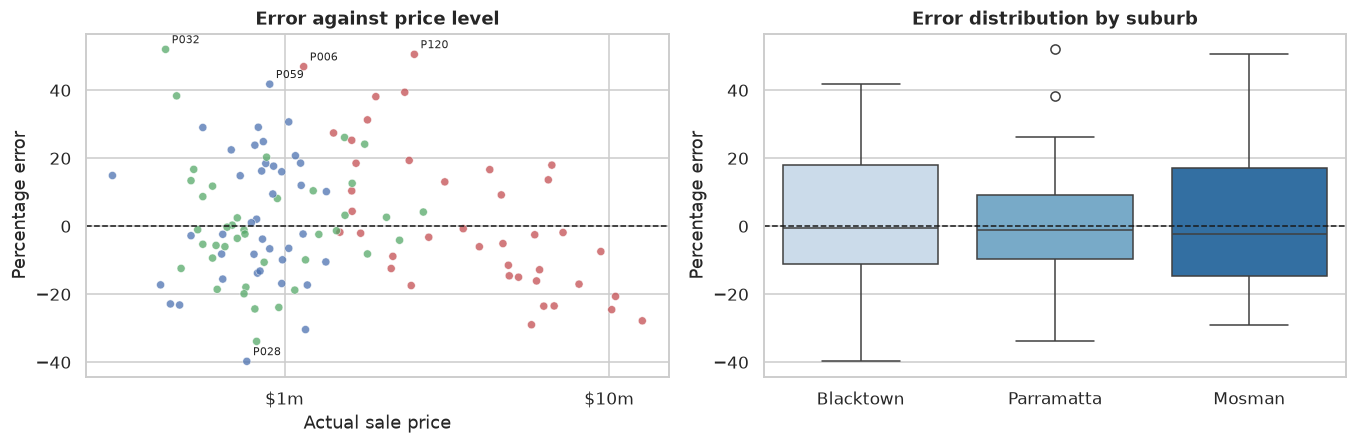

12 most expensive sales - mean signed error: $-1,092,832 (-13.6%)
12 cheapest sales      - mean signed error: $24,022 (+5.1%)


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].scatter(audit.sale_price, audit.error / audit.sale_price * 100,
                c=audit.suburb.map({"Blacktown": "#4C72B0", "Parramatta": "#55A868",
                                    "Mosman": "#C44E52"}),
                s=28, alpha=0.75, edgecolor="white", lw=0.4)
axes[0].axhline(0, color="k", lw=1, ls="--")
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda v, p: f"${v/1e6:.0f}m" if v >= 1e6 else f"${v/1e3:.0f}k"))
axes[0].set_xlabel("Actual sale price"); axes[0].set_ylabel("Percentage error")
axes[0].set_title("Error against price level")
for _, r in worst.iterrows():
    axes[0].annotate(r.property_id, (r.sale_price, r.error / r.sale_price * 100),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")

sns.boxplot(data=audit.assign(pct=audit.error / audit.sale_price * 100),
            x="suburb", y="pct", order=order, ax=axes[1], palette="Blues")
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set_ylabel("Percentage error"); axes[1].set_xlabel("")
axes[1].set_title("Error distribution by suburb")

plt.tight_layout(); plt.savefig(FIG / "fig10_error_analysis.png"); plt.show()

top10 = audit.nlargest(12, "sale_price")
print(f"12 most expensive sales - mean signed error: "
      f"${top10.error.mean():,.0f} ({100*top10.error.mean()/top10.sale_price.mean():+.1f}%)")
bot = audit.nsmallest(12, "sale_price")
print(f"12 cheapest sales      - mean signed error: "
      f"${bot.error.mean():,.0f} ({100*bot.error.mean()/bot.sale_price.mean():+.1f}%)")

## 4.1 What the failures have in common

Read together, the five cases point at three distinct weaknesses rather than
five unrelated mistakes.

**The model leans too hard on the suburb.** Four of the five worst errors are
over-predictions, and each one is a *small or compromised dwelling in an
expensive location*: a 42 sqm two-bedroom Parramatta apartment, a one-bedroom
Mosman apartment, a three-bedroom Mosman townhouse in original condition, and a
Blacktown house needing full renovation. Suburb is by far the strongest feature,
so the model starts from the suburb level and then applies adjustments that are
too small to bring an unusually modest property all the way down. The
suburb-level bias table shows the same effect in aggregate: Mosman carries a
bias of -&#36;279k while Blacktown and Parramatta are mildly positive.

**Compression at both ends.** The signed-error check shows the twelve most
expensive sales under-predicted by 13.6% on average, while the twelve cheapest
are over-predicted by 5.1%. For a linear model on log price this is ordinary
regression toward the mean: the fitted surface is a compromise across the whole
range, and at the extremes the residual premium or discount is precisely what
the available features fail to explain. Note this would have had a *different*
cause had a tree model been deployed - ensembles average over training leaves
and so cannot predict outside the observed range at all. Same symptom, different
mechanism, and worth distinguishing because the remedies differ: the linear
model needs better features at the extremes, whereas a tree model would need
more data there no matter how good the features were.

**Thin segments.** Errors concentrate where the model has few comparable sales
to learn from. Mosman has only six townhouse sales and Blacktown only five, and
both suburbs contribute a townhouse to the worst-five list. With so few
examples, the model effectively prices these as a small correction to the
suburb's dominant dwelling type rather than on their own terms.

## 4.2 Information that would have helped

Ranked by how much I would expect each to reduce the errors above:

1. **Aspect, outlook and position**, as structured fields rather than prose -
   a view rating, whether the block is level, north-facing, on a main road.
   This is the single largest unmeasured driver in Mosman.
2. **Renovation standard and date**, with an indication of spend. "Renovated"
   currently spans a &#36;30k cosmetic refresh and a &#36;600k rebuild.
3. **Strata levies and building age** for apartments, which materially affect
   what a buyer will pay for an otherwise identical unit.
4. **Sale context** - number of registered bidders, whether the property was
   passed in first, whether it was a deceased estate or a distressed sale.
5. **School catchment**, which is a well-documented price driver in Sydney and
   is entirely absent here.

## 4.3 When should these predictions be distrusted?

The model should be treated as advisory, not authoritative, when:

- the property is **unusually small or modest for its suburb**, which is the
  single clearest pattern in the failures above - the model will start from the
  suburb level and not come down far enough;
- the property is **above roughly &#36;5m**, where compression bites hardest and
  comparable sales are scarce;
- the listing mentions **waterfront, harbour views or development potential**,
  because those premiums are large, variable, and only weakly captured;
- the dwelling is a **rare type for its suburb** (a house in the Parramatta
  apartment belt, a 1-bedroom unit in Mosman);
- the property is in **unusual condition** at either extreme.

Some property types are inherently harder to model, and that is worth stating in
the tool rather than papering over. Standard stock in a deep market - a
3-bedroom Blacktown house, a 2-bedroom Parramatta apartment - has many near
identical comparables and prices predictably. Prestige property is close to a
one-off good: it is priced by a small number of buyers on attributes that
resist being put in a column. No amount of modelling fixes that; it is a
property of the market, not of the algorithm.

---
# Part 5 - Deployment

## 5.1 Choosing the deployed model

The recommendation is made on cross-validated percentage error, with the
suburb-level breakdown checked to confirm the winner is not simply good at the
largest segment.

In [31]:
final_name = min(results, key=lambda k: results[k]["MAPE (%)"])
print(f"Recommended model: {final_name}")
print(f"  cross-validated MAPE       {results[final_name]['MAPE (%)']:.1f}%")
print(f"  cross-validated median APE {results[final_name]['Median APE (%)']:.1f}%")
print(f"  cross-validated MAE        ${results[final_name]['MAE ($)']:,.0f}")
print(f"  R2 on log price            {results[final_name]['R2 (log)']:.3f}")

final_model = models[final_name].fit(X, y)

resid = y - cv_predictions[final_name]
sigma = resid.std()
lo, hi = np.exp(-1.96 * sigma), np.exp(1.96 * sigma)
print(f"\nresidual sd (log) = {sigma:.3f}")
print(f"-> 95% interval is roughly x{lo:.2f} to x{hi:.2f} of the point estimate")
print(f"   e.g. a $1,200,000 estimate spans ${1.2e6*lo:,.0f} to ${1.2e6*hi:,.0f}")

Recommended model: Ridge regression
  cross-validated MAPE       15.2%
  cross-validated median APE 13.5%
  cross-validated MAE        $332,832
  R2 on log price            0.953

residual sd (log) = 0.185
-> 95% interval is roughly x0.70 to x1.44 of the point estimate
   e.g. a $1,200,000 estimate spans $834,238 to $1,726,126


In [32]:
import joblib

APP = Path("app"); APP.mkdir(exist_ok=True)

bundle = {
    "pipeline": final_model,
    "model_name": final_name,
    "features": FEATURES,
    "numeric": NUMERIC,
    "categorical": CATEGORICAL,
    "text_patterns": TEXT_PATTERNS,
    "land_fill_sqm": LAND_FILL_SQM,
    "residual_sigma": float(sigma),
    "metrics": results[final_name],
    "trained_rows": int(len(X)),
    "target": "log(sale_price)",
    "suburbs": order,
    "property_types": ["House", "Townhouse", "Apartment"],
    "conditions": ["Needs work", "Original", "Good", "Renovated", "New"],
    "sale_methods": ["Auction", "Private treaty"],
    "cbd_km": df.groupby("suburb")["distance_to_cbd_km"].median().to_dict(),
}
joblib.dump(bundle, APP / "model.joblib")
print(f"saved app/model.joblib  ({(APP/'model.joblib').stat().st_size/1024:.0f} KB)")

sample = df.iloc[[0]].copy()
check = engineer(sample)[FEATURES]
print(f"\nsmoke test on {sample.property_id.iloc[0]}: "
      f"predicted ${np.exp(final_model.predict(check))[0]:,.0f}, "
      f"actual ${sample.sale_price.iloc[0]:,.0f}")

saved app/model.joblib  (9 KB)

smoke test on P001: predicted $2,152,754, actual $1,800,000


In [33]:
cv_table.to_csv("figures/cv_results.csv")
by_suburb.to_csv("figures/error_by_suburb.csv")
worst[display_cols].to_csv("figures/worst_predictions.csv", index=False)
imp.to_frame("importance").to_csv("figures/importance.csv")
print("wrote metric tables to figures/")
cv_table.round(3)

wrote metric tables to figures/


,MAE ($),RMSE ($),MAPE (%),Median APE (%),R2 (log)
Ridge regression,"332,831.527","618,401.523",15.244,13.517,0.953
Random Forest,"512,669.937","1,221,344.795",19.499,15.728,0.901
Gradient Boosting,"418,634.182","885,450.849",17.279,14.432,0.936


## 5.2 The application

The deployed app is a Streamlit page in `app/streamlit_app.py`. It loads
`app/model.joblib`, rebuilds the same engineered features through the exported
`engineer()` logic, and returns a point estimate with an interval.

Three decisions shaped it:

- **It reuses the trained pipeline object, not a re-implementation.** Imputation,
  scaling and one-hot encoding are all inside the saved pipeline, so the app
  cannot drift out of sync with training - the classic source of
  training/serving skew.
- **It always shows an interval**, derived from the cross-validated residual
  spread, rather than a single confident number. For a decision support tool the
  uncertainty is part of the answer.
- **It warns when the input is outside the model's competence** - above &#36;5m, a
  rare dwelling type for the suburb, or a waterfront mention - using the
  findings from Part 4.

It accepts a single property entered in the sidebar, or a CSV upload for batch
scoring.

**To run it:**

```bash
cd SIT307_8.1D_Submission
.venv/bin/streamlit run app/streamlit_app.py
```

Then open http://localhost:8501.

## 5.3 Reflection

**What the workflow actually taught me.** The modelling was the smallest part of
the project. Deciding to predict log price, working out that Parramatta's low
median was a dwelling-mix artefact rather than a cheap suburb, and recognising
that `distance_to_cbd_km` was impersonating the suburb label - each of those
came from looking at the data, and each changed the result more than any
hyperparameter did. The complexity sweep in Part 3 makes the point: moving
`min_samples_leaf` across its whole sensible range shifts cross-validated R²
by a few hundredths, while the log transform and the text features move it far
more.

**Where the difficulty concentrated.** Feature engineering, and specifically the
missing-data decisions. Imputing a median block size for apartments would have
been the default behaviour of a naive pipeline and would have quietly taught the
model that apartments sit on land. Separating structural from incidental
missingness took more thought than fitting all three models.

**Performance against deployability.** I expected this to be a genuine trade-off
and had prepared to argue for accepting a less explainable model. The data
declined to cooperate: the most accurate model here is also the most
interpretable one, and it is the smallest artefact to ship at 9 KB. That is a
convenient outcome, but I do not think it generalises - it happened because the
dataset is small enough that the flexible models overfit, and on a few thousand
real sales the ensembles would likely overtake Ridge and the trade-off would
reappear. The lasting lesson is the ordering: establish the simple baseline
first, because on a dataset this size it may simply win, and a complex model
that loses to a linear baseline is not worth deploying whatever its appeal.

The real deployment tension turned out to be elsewhere - in the width of the
interval. A residual standard deviation of 0.185 in log space means the honest
95% range runs from about 0.70x to 1.44x the point estimate: on a &#36;1.2m
estimate, roughly &#36;834k to &#36;1.73m. That is too wide to be useful as a price
guide, and reporting only the point estimate would have concealed it. Showing
the interval is the difference between a decision support tool and a tool that
invents false precision, even though it makes the output look considerably less
impressive.

**Bias and fairness.** Three concerns are worth stating plainly. The dataset
contains only sold properties, so it encodes the prices the market accepted and
will be optimistic about stock that struggles to sell. Automated valuation
applied at scale is self-reinforcing: if agents price to the model and the model
learns from resulting sales, its errors become the market's. And a model trained
on three suburbs will produce a confident-looking number for a fourth it has
never seen - which is why the app restricts the suburb field to the three it
was trained on rather than accepting free text.

**With more data, time or resources.** More rows would help most, particularly
in the thin segments - the top of the Mosman market and the rare dwelling types
- since the learning curves in Part 3 are still rising at 120 rows. After that I
would add the structured outlook and renovation-quality fields identified in
Part 4, replace the keyword flags with embeddings of the full agent description
now that there would be enough rows to support it, and move from a single
5-fold split to repeated cross-validation so the model comparison carries an
honest confidence interval. A time-aware validation split - training on earlier
sales and testing on later ones - would also be a fairer test of how the tool
would actually be used.

In [34]:
print(f"Deployed model : {final_name}")
print(f"Trained on     : {len(X)} properties, {X.shape[1]} features")
print(f"CV MAPE        : {results[final_name]['MAPE (%)']:.1f}%")
print(f"Artefact       : app/model.joblib")
print(f"Figures        : {len(list(FIG.glob('*.png')))} written to figures/")

Deployed model : Ridge regression
Trained on     : 120 properties, 29 features
CV MAPE        : 15.2%
Artefact       : app/model.joblib
Figures        : 10 written to figures/
